## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv'
df = pd.read_csv(url)

df = df.drop(columns=['total_litres_of_pure_alcohol'])

tidy_df = pd.melt(df, id_vars=['country'], var_name='drink', value_name='servings')
tidy_df

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217
...,...,...,...
574,Venezuela,wine_servings,3
575,Vietnam,wine_servings,1
576,Yemen,wine_servings,0
577,Zambia,wine_servings,4


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [2]:
tidy_df['drink'] = tidy_df['drink'].str.replace('_servings', '')
tidy_df

,country,drink,servings
0,Afghanistan,beer,0
1,Albania,beer,89
2,Algeria,beer,25
3,Andorra,beer,245
4,Angola,beer,217
...,...,...,...
574,Venezuela,wine,3
575,Vietnam,wine,1
576,Yemen,wine,0
577,Zambia,wine,4


C:\Users\pixls\AppData\Local\Temp\ipykernel_12176\2953690764.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=beer_top10, x='servings', y='country', ax=axes[0], palette='Blues_d')
C:\Users\pixls\AppData\Local\Temp\ipykernel_12176\2953690764.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wine_top10, x='servings', y='country', ax=axes[1], palette='Reds_d')
C:\Users\pixls\AppData\Local\Temp\ipykernel_12176\2953690764.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=spirit_top10, x='servings', y='country', ax=axes[2], 

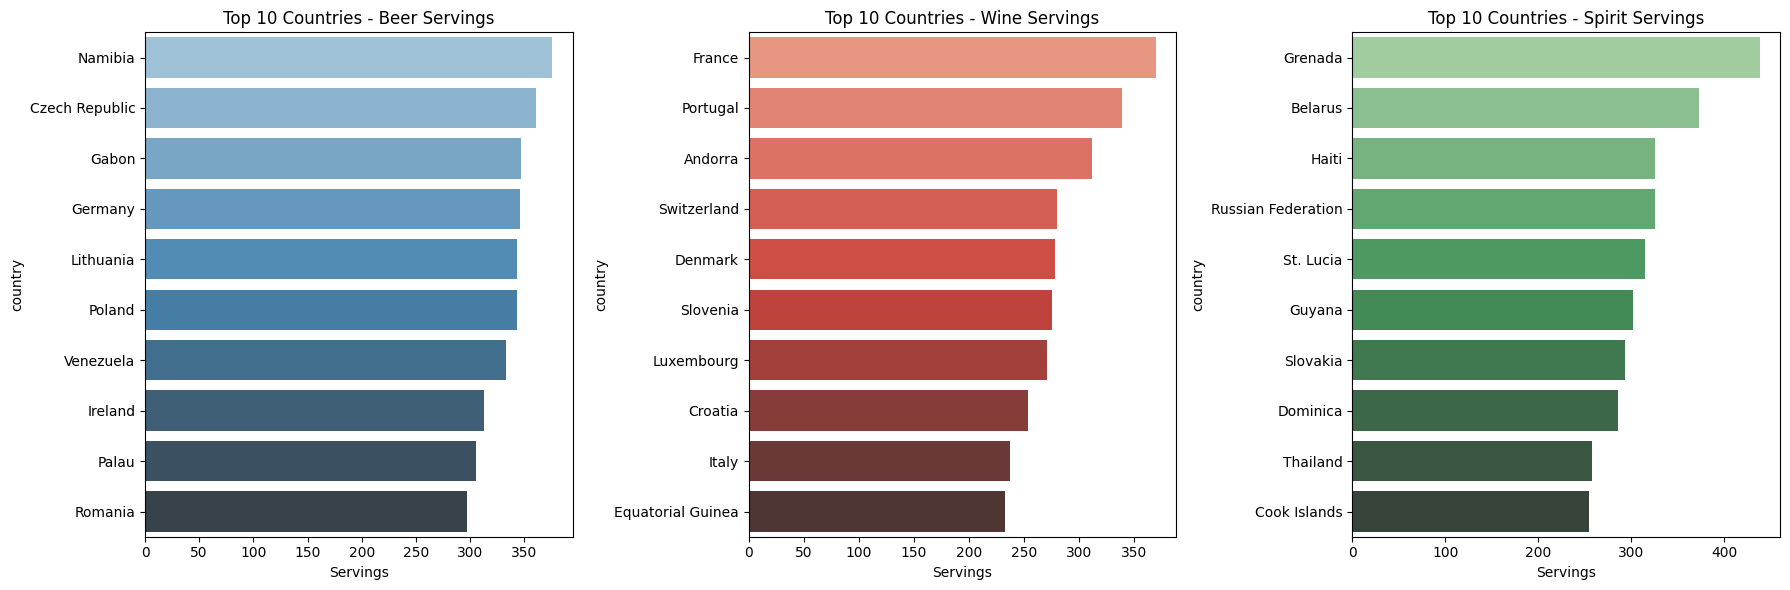

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

beer_top10 = tidy_df[tidy_df['drink'] == 'beer'].nlargest(10, 'servings')
sns.barplot(data=beer_top10, x='servings', y='country', hue='country', ax=axes[0], palette='Blues_d', legend=False)
axes[0].set_title('Top 10 Countries - Beer Servings')
axes[0].set_xlabel('Servings')

wine_top10 = tidy_df[tidy_df['drink'] == 'wine'].nlargest(10, 'servings')
sns.barplot(data=wine_top10, x='servings', y='country', hue='country', ax=axes[1], palette='Reds_d', legend=False)
axes[1].set_title('Top 10 Countries - Wine Servings')
axes[1].set_xlabel('Servings')

spirit_top10 = tidy_df[tidy_df['drink'] == 'spirit'].nlargest(10, 'servings')
sns.barplot(data=spirit_top10, x='servings', y='country', hue='country', ax=axes[2], palette='Greens_d', legend=False)
axes[2].set_title('Top 10 Countries - Spirit Servings')
axes[2].set_xlabel('Servings')

plt.tight_layout()
plt.show()

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [4]:
wide_df = tidy_df.pivot_table(index='country', columns='drink', values='servings')
wide_df

drink,beer,spirit,wine
country,,,
Afghanistan,0.0,0.0,0.0
Albania,89.0,132.0,54.0
Algeria,25.0,0.0,14.0
Andorra,245.0,138.0,312.0
Angola,217.0,57.0,45.0
...,...,...,...
Venezuela,333.0,100.0,3.0
Vietnam,111.0,2.0,1.0
Yemen,6.0,0.0,0.0
